## ✅ Week 1: Linear & Logistic Regression (Done Properly)

### Day 1–2

Implement from scratch in NumPy:

- Linear regression
- Vectorized cost function
- Vectorized gradients
- Batch gradient descent

Add:

- Feature normalization
- Learning rate experimentation
- Cost tracking over iterations

You should be able to:

- Explain every dimension of every matrix
- Derive the gradient without looking

## 1️⃣ Problem Definition

- What model are we implementing?
- What equations define it?
- What are we trying to observe?



## Steps to calculate cost function:
1. Compute squared error
2. Sum across m examples
3. Divide sum by 2 * m
$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_w,b(x^{(i)}) - y^{(i)})^2$$

## Gradient Descent
Updates each parameter by moving it slightly in the direction of the the lowest possible cost
$$w := w - \alpha \frac{\partial}{\partial w} J(w, b)$$
$$\frac{\partial}{\partial w} J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) * x_j^{(i)} $$

- Even with fixed $\alpha$, step size automatically shrinks because the magnitude of the derivative decreases as we approach the minimum




## 3️⃣ Section 3 — Code Structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# data generation
m = 100
n = 5 # number of features
X = 2 * np.random.rand(m,n)
w = np.zeros(n)
b = 0.0

# Generate targets correctly
true_w = np.array([3,-2,1,4,0.5])
true_b = 5
y = X @ true_w + true_b * np.random.randn(m)

In [ ]:
def compute_cost(X,y,w,b, lambda_ = 1):
    m = X.shape[0]
    n = len(w)
    y_hat = X @ w + b
    

    # MSE
    error = y_hat - y
    cost = (1/(2*m)) * np.sum(error**2)

    # With L2 Regularization
    reg_cost = 0
    reg_cost = (lambda_/(2 * m)) * np.sum(w**2)
    
    total_cost = cost + reg_cost
    return total_cost    
    

In [4]:
def compute_gradients(X,y,w,b):
    m = X.shape[0]
    y_hat = X@w + b
    error = y_hat - y
    
    dw = (1/m) * (X.T @ error)
    db = (1/m) * np.sum(error)
    return dw,db

In [14]:
def gradient_descent(X,y,w,b, alpha, num_iters):
    cost = []
    for i in range(num_iters):
        dw, db = compute_gradients(X,y,w,b)
        w -= alpha * dw
        b -= alpha * db

        #Save cost at each iteration
        
        cost.append(compute_cost(X,y,w,b))
        #Print cost at 
        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {cost[-1]:.2e}")
            print(f"dw: {dw}, db: {db}")
            print(f"w: {w}, b: {b}\n")

        
    
    return w,b, cost

Run Training

In [6]:
w =np.zeros(n)
b = 0.0

Train:

In [15]:
w_final, b_final, cost = gradient_descent(X, y, w, b, alpha=0.09, num_iters=1000)
print(f"(w,b) found by gradient descent: ({w_final}, {b_final})")

Iteration    0: Cost 1.34e+01
dw: [-0.8443425   0.43876877 -0.67207194 -1.30239273 -0.48014321], db: -0.36745419792741124
w: [1.5813939  1.00808423 1.40034473 2.04907376 1.34538186], b: 0.03307087781346701

Iteration  100: Cost 1.15e+01
dw: [-0.01554297  0.02188361  0.0154414  -0.04105068 -0.01653507], db: 0.04532700218187951
w: [ 2.37278819 -1.30031281  1.46169366  3.95991216  1.48475553], b: -0.634318604042648

Iteration  200: Cost 1.15e+01
dw: [-0.00463828 -0.00549252 -0.00148634 -0.00718713 -0.0069544 ], db: 0.027847915515418844
w: [ 2.44617757 -1.31026401  1.4228974   4.11542032  1.58248583], b: -0.9523160730119211

Iteration  300: Cost 1.15e+01
dw: [-0.00250521 -0.00461836 -0.00253059 -0.00354486 -0.00385894], db: 0.018119279207324077
w: [ 2.47659836 -1.26265197  1.44449364  4.15956334  1.62873575], b: -1.1554329998761637

Iteration  400: Cost 1.15e+01
dw: [-0.00156385 -0.00309841 -0.00181628 -0.00224617 -0.00244202], db: 0.011838493466955109
w: [ 2.49443434 -1.22830539  1.464127

## Early diagnostics
Plot:

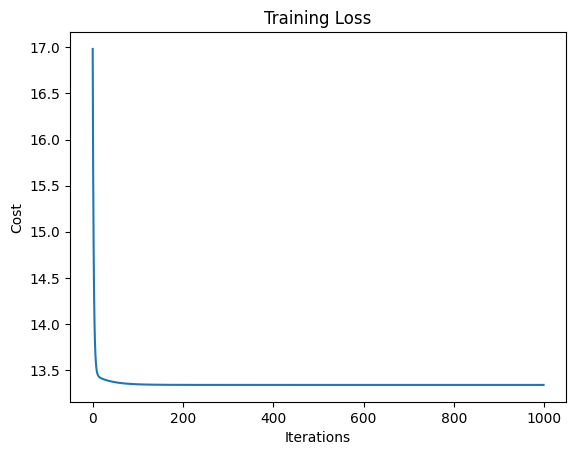

In [ ]:
plt.plot(costs)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

## Experiments on different values of alpha and number of iterations:
- The green zone: When the line drops sharply at the beginning and then slowly begins to level out. When the alpha value is between 0.05 and 1, our model achieves this
- The slow zone: When the number of iterations is too little, or the alpha value is too small, the graph doesn't level out in time. The line points downwards but never levels in time
- The Exploding zone: When the alpha value is bodacious, the line goes up instead of down, because the gradient descent misses the minimum point entirely.

## Feature Normalization


In [ ]:
def zscore_normalize_features(X):
    # find the mean of each column/feature
    mu = np.mean(X, axis=0)
    #find the standard deviation of each column/feature
    sigma = np.std(X, axis=0)
    # element-wise, subtract mu for that column for each example, divide by std for that column
    X_norm = (X- mu)/sigma

    return X_norm, mu, sigma

In [ ]:
X_norm, mu, sigma = zscore_normalize_features(X)

print(f"X_mu = {mu}, \n X_sigma = {sigma}")
print(f"Peak to Peak range by column in Raw Dataset:   X:{np.ptp(X, axis=0)}")
print(f"Peak to Peak range by column in Normalized     X:{np.ptp(X_norm, axis=0)}")


X_mu = [1.03073548], 
 X_sigma = [0.60211747]
Peak to Peak range by column in Raw Dataset:   X:[1.97063251]
Peak to Peak range by column in Normalized     X:[3.2728373]
